<div style="text-align: center;">
  <img src="./imagens/logo_novaims.png" alt="Logo" style="width: 150px; height: auto; margin-bottom: 10px;">
  <h1 style="margin: 0;"><strong>Data Mining Project: Amazing International Airlines Inc.</strong></h1>
  <h2 style="margin: 0;"><strong>Part 1/2: Exploratory Data Analysis</strong></h2>
</div>

<div style="text-align: left; margin-top: 15px;">
  <p style="margin: 0;"><strong>Group 51:</strong></p>
  <ul style="margin: 0; padding-left: 20px;">
    <li>André Ferreira | 20250398</li>
    <li>Fausto Gomes | 20221915</li>
    <li>Maria Francisca Gonçalves | 20221942</li>
    <li>Miguel Matos | 20221925</li>
  </ul>
</div>

---
#### <font> Table of Contents </font> <a class="anchor" id='toc'></a> 
0. [Context](#introduction)
1. [Imports](#Imports)  
2. [Exploratory Data Analysis - Customer Data](#exploratory-data-analysis)

- 2.1. [Data Understanding](#21-data-understanding)
  - 2.1.1.[Descriptive Analysis](#descriptive-analysis)
  - 2.1.2.[Visualizations](#visualizations)

- 2.2. [GeoData](#geodata)

- 2.3. [Data Cleaning](#data-cleaning)



----

# <span style="color:#0097b2">1. Imports</span>
[Back to TOC](#toc)

In [196]:
from utils.functions import *

data = pd.read_csv("../data/cleaned_data/clustering_data_cleaned.csv", index_col = 'Loyalty#')

pd.set_option("display.max_columns", None)

# <span style="color:#0097b2">Data Segmentation</span>
[Back to TOC](#toc)

In [197]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16663 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          16663 non-null  int64  
 1   Income                          16663 non-null  float64
 2   Customer Lifetime Value         16663 non-null  float64
 3   EnrollmentType                  16663 non-null  int64  
 4   rejoined_program                16663 non-null  int64  
 5   Days_in_prog                    16663 non-null  float64
 6   Cancelled_program               16663 non-null  int64  
 7   Enrollment_year                 16663 non-null  int64  
 8   Enrollment_month                16663 non-null  int64  
 9   Location_cluster                16663 non-null  int64  
 10  TotalFlights                    16663 non-null  float64
 11  TotalDistance                   16663 non-null  float64
 12  TotalPointsAccumulated         

## Value-based segmentation

In [198]:
value_based_data = data[["Customer Lifetime Value", "Income", "TotalPointsAccumulated", 
                              "TotalPointsRedeemed"]]

### Feature Selection
[Back to TOC](#toc)

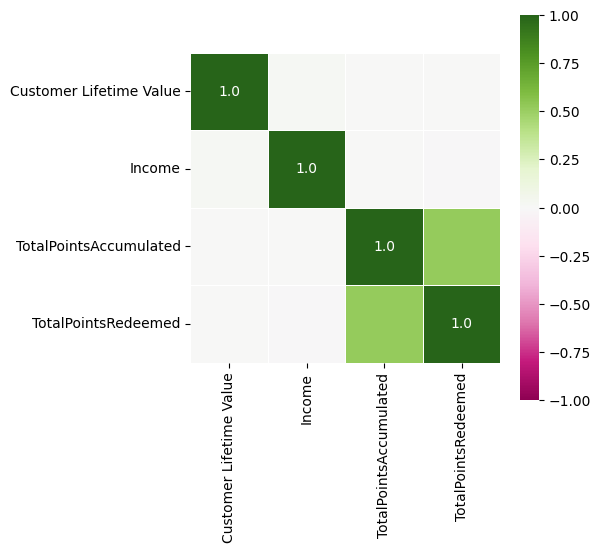

In [199]:
correlation_matrix(value_based_data, 0.7, 5, 5)

In [200]:
value_based_data.to_csv("../data/clustering_data/value_based_data.csv")

In [201]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16663 entries, 100011 to 999999
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          16663 non-null  int64  
 1   Income                          16663 non-null  float64
 2   Customer Lifetime Value         16663 non-null  float64
 3   EnrollmentType                  16663 non-null  int64  
 4   rejoined_program                16663 non-null  int64  
 5   Days_in_prog                    16663 non-null  float64
 6   Cancelled_program               16663 non-null  int64  
 7   Enrollment_year                 16663 non-null  int64  
 8   Enrollment_month                16663 non-null  int64  
 9   Location_cluster                16663 non-null  int64  
 10  TotalFlights                    16663 non-null  float64
 11  TotalDistance                   16663 non-null  float64
 12  TotalPointsAccumulated         

## Behavioral segmentation

In [202]:
behavioral_data = data[["TotalFlights", "TotalPointsAccumulated", "TotalDistance", "RecencyInMonths", "Days_in_prog",
                        
                        "Pct_Spend_Month_1", "Pct_Spend_Month_2", "Pct_Spend_Month_3", "Pct_Spend_Month_4", "Pct_Spend_Month_5", 
                        "Pct_Spend_Month_6", "Pct_Spend_Month_7", "Pct_Spend_Month_8", "Pct_Spend_Month_9", "Pct_Spend_Month_10", 
                        "Pct_Spend_Month_11", "Pct_Spend_Month_12",
                        
                        "PctFlightsWithCompanions",	"PctPointsSpent"]]

Total Spends per month will not be used as they become redundant when gathers with the percentages per month.

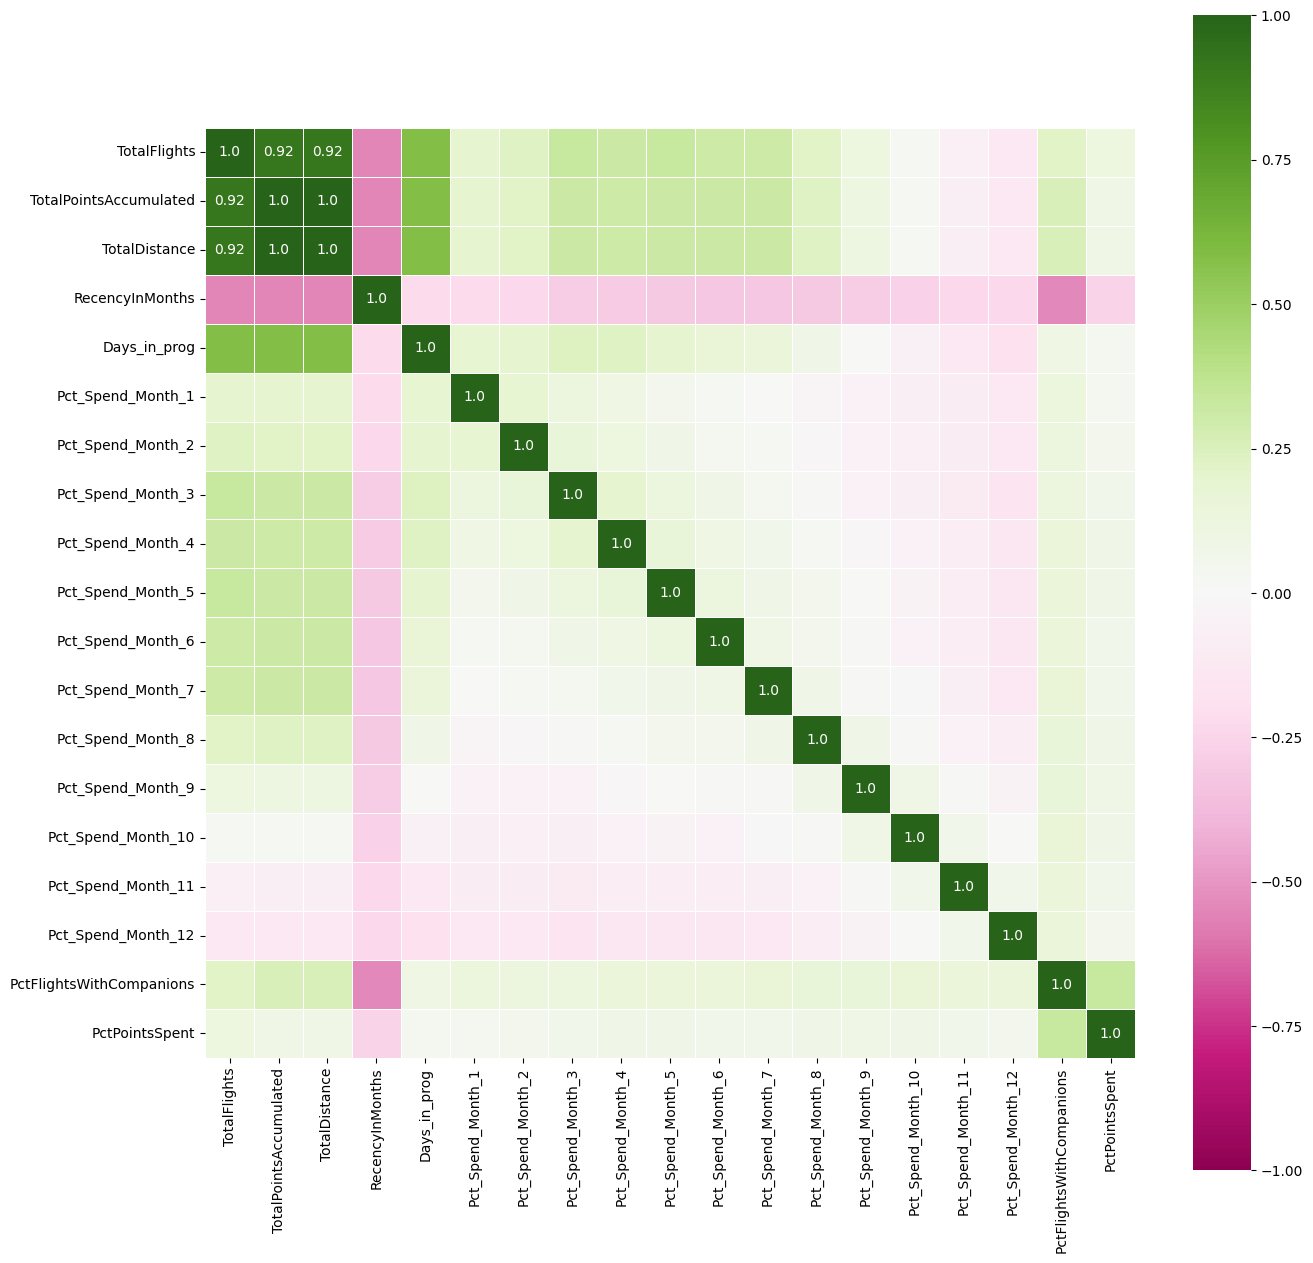

In [203]:
correlation_matrix(behavioral_data, 0.7, 15, 15)

We will keep TotalPointsAccumulated, because it's the most comprehensive engagement metric, out of the three highly correlated features.

In [204]:
behavioral_data = behavioral_data.drop(columns = ["TotalFlights", "TotalDistance"])

In [205]:
behavioral_data.to_csv("../data/clustering_data/behavioral_data.csv")

## Demographic segmentation

In [206]:
demographic_data = data[["Income", "Enrollment_year", "Days_in_prog", "Location_cluster"]]

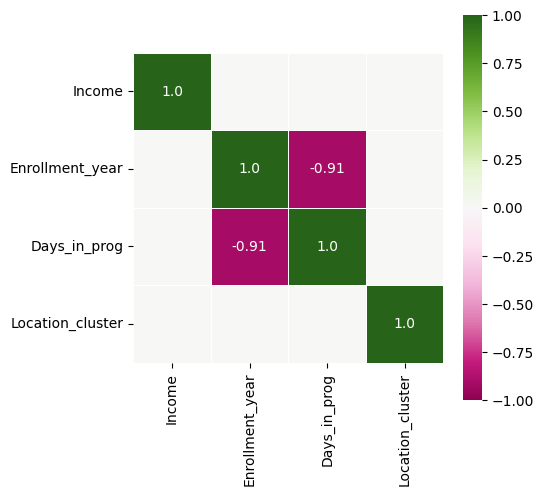

In [207]:
correlation_matrix(demographic_data, 0.7, 5, 5)

In [208]:
demographic_data = demographic_data.drop(columns= ["Enrollment_year"])

In [209]:
demographic_data.to_csv("../data/clustering_data/demographic_data.csv")